# Pipeline Klasifikasi Aksara Jawa - PyTorch

Pipeline ini mencakup:
1. Data Loading dan Preprocessing
2. Exploratory Data Analysis
3. CNN Pre-trained Model Training (PyTorch + timm)
4. Feature Extraction
5. Ensemble Model (KNN, Logistic Regression, SVC)

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from PIL import Image

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [34]:
print("="*60)
print("GPU/CUDA Configuration Check")
print("="*60)

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda if torch.cuda.is_available() else 'N/A'}")
print(f"cuDNN version: {torch.backends.cudnn.version() if torch.cuda.is_available() else 'N/A'}")

if torch.cuda.is_available():
    print(f"\nGPU count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.2f} GB")
    
    device = torch.device('cuda')
    x = torch.randn(100, 100).to(device)
    y = torch.randn(100, 100).to(device)
    z = torch.matmul(x, y)
    print(f"\nTest computation on GPU: SUCCESS")
else:
    print("\nWARNING: No GPU detected!")
    print("Running on CPU - Training will be slower")
    device = torch.device('cpu')

print(f"\nDevice set to: {device}")
print("="*60)

GPU/CUDA Configuration Check

PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA version: 12.4
cuDNN version: 90300

GPU count: 2
GPU 0: Tesla T4
  Memory: 14.74 GB
GPU 1: Tesla T4
  Memory: 14.74 GB

Test computation on GPU: SUCCESS

Device set to: cuda


## 1. Data Loading dan Preprocessing

In [36]:
IMG_SIZE = 224
BATCH_SIZE = 32

class AksaraJawaDataset(Dataset):
    def __init__(self, root_dir, transform=None, preprocess=True):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.preprocess = preprocess
        self.images = []
        self.labels = []
        
        for class_folder in sorted(self.root_dir.iterdir()):
            if class_folder.is_dir():
                class_name = class_folder.name
                for img_path in class_folder.glob('*'):
                    if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                        self.images.append(str(img_path))
                        self.labels.append(class_name)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if self.preprocess:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.equalizeHist(img)
            img = cv2.GaussianBlur(img, (3, 3), 0)
        else:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = Image.fromarray(img)
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = AksaraJawaDataset('/kaggle/input/aksara-jawa/v3/v3/train', transform=train_transform)
val_dataset = AksaraJawaDataset('/kaggle/input/aksara-jawa/v3/v3/val', transform=val_transform)

label_encoder = LabelEncoder()
all_labels = train_dataset.labels + val_dataset.labels
label_encoder.fit(all_labels)

num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")
print(f"\nTraining samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Number of classes: 20
Classes: ['ba' 'ca' 'da' 'dha' 'ga' 'ha' 'ja' 'ka' 'la' 'ma' 'na' 'nga' 'nya' 'pa'
 'ra' 'sa' 'ta' 'tha' 'wa' 'ya']

Training samples: 2154
Validation samples: 480


## 2. Exploratory Data Analysis

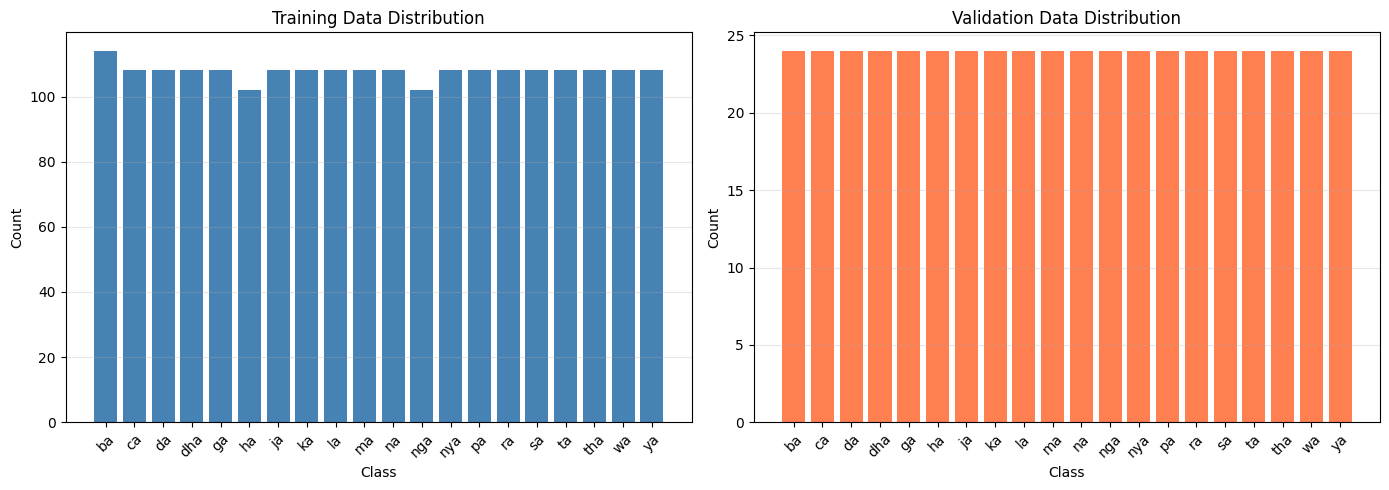


Training data distribution:
ba     114
ca     108
da     108
dha    108
ga     108
ha     102
ja     108
ka     108
la     108
ma     108
na     108
nga    102
nya    108
pa     108
ra     108
sa     108
ta     108
tha    108
wa     108
ya     108
Name: count, dtype: int64

Mean: 107.70, Std: 2.36

Validation data distribution:
ba     24
ca     24
da     24
dha    24
ga     24
ha     24
ja     24
ka     24
la     24
ma     24
na     24
nga    24
nya    24
pa     24
ra     24
sa     24
ta     24
tha    24
wa     24
ya     24
Name: count, dtype: int64

Mean: 24.00, Std: 0.00


In [37]:
train_counts = pd.Series(train_dataset.labels).value_counts().sort_index()
val_counts = pd.Series(val_dataset.labels).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(train_counts.index, train_counts.values, color='steelblue')
axes[0].set_title('Training Data Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(val_counts.index, val_counts.values, color='coral')
axes[1].set_title('Validation Data Distribution')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTraining data distribution:")
print(train_counts)
print(f"\nMean: {train_counts.mean():.2f}, Std: {train_counts.std():.2f}")

print("\nValidation data distribution:")
print(val_counts)
print(f"\nMean: {val_counts.mean():.2f}, Std: {val_counts.std():.2f}")

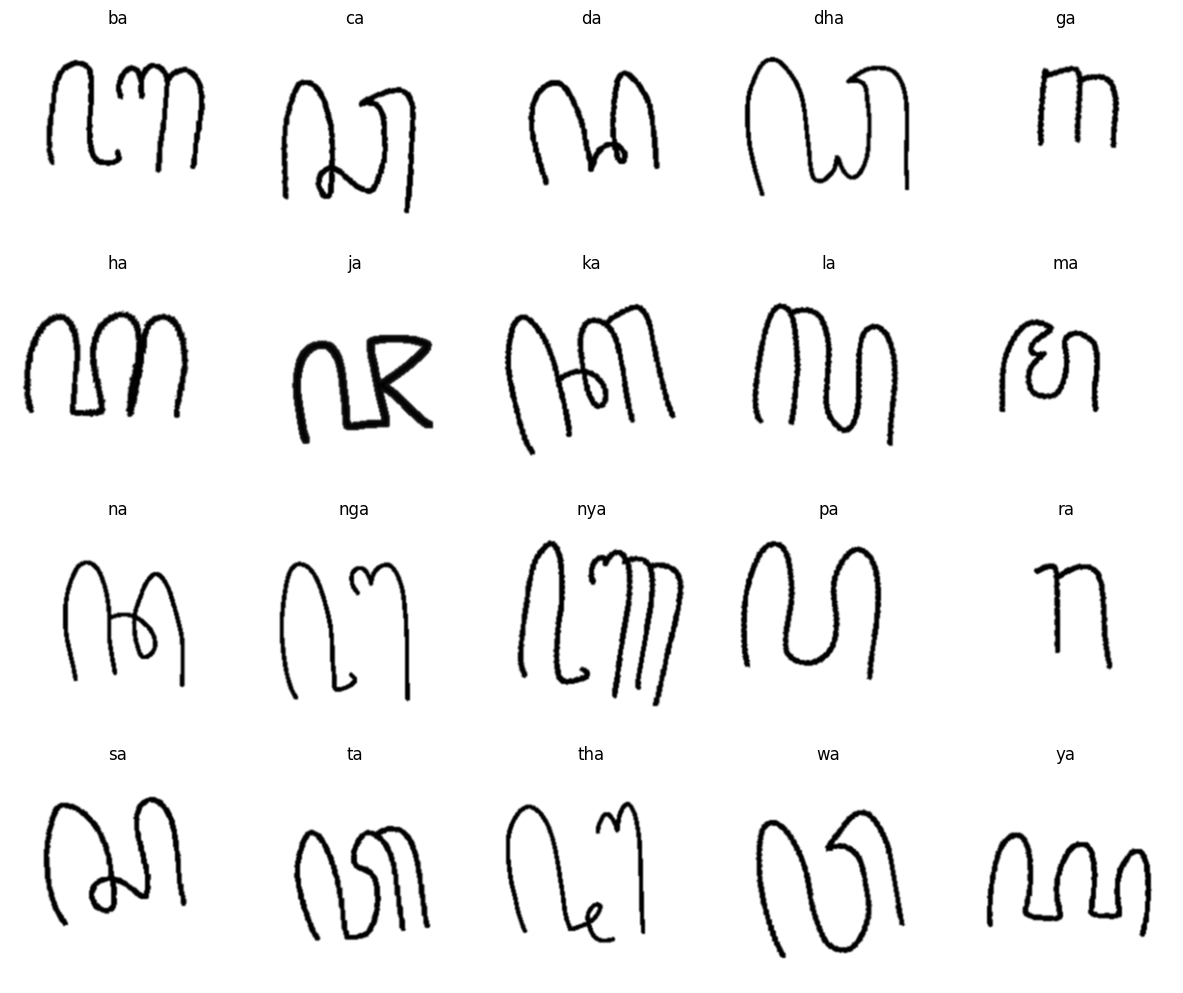

In [39]:
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.ravel()

sample_dataset = AksaraJawaDataset('/kaggle/input/aksara-jawa/v3/v3/train', transform=None, preprocess=True)

for idx, class_name in enumerate(label_encoder.classes_):
    class_indices = [i for i, label in enumerate(sample_dataset.labels) if label == class_name]
    if class_indices:
        sample_idx = class_indices[0]
        img, _ = sample_dataset[sample_idx]
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(class_name)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 3. CNN Pre-trained Model Training

In [40]:
class LabelEncodedDataset(Dataset):
    def __init__(self, dataset, label_encoder):
        self.dataset = dataset
        self.label_encoder = label_encoder
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        label_encoded = self.label_encoder.transform([label])[0]
        return img, label_encoded

train_dataset_encoded = LabelEncodedDataset(train_dataset, label_encoder)
val_dataset_encoded = LabelEncodedDataset(val_dataset, label_encoder)

train_loader = DataLoader(train_dataset_encoded, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset_encoded, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Train batches: 68
Validation batches: 15


In [41]:
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=num_classes)
model = model.to(device)

print(f"Model: efficientnet_b0")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model: efficientnet_b0
Number of parameters: 4,033,168
Trainable parameters: 4,033,168


In [42]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(train_loader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

print("Training functions defined")

Training functions defined


In [43]:
NUM_EPOCHS = 50
best_val_acc = 0
patience = 10
patience_counter = 0

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print(f"Starting training on {device}...")
print("="*60)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    scheduler.step(val_loss)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Best model saved with accuracy: {best_val_acc:.2f}%")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

print("\n" + "="*60)
print("Training completed!")
print(f"Best validation accuracy: {best_val_acc:.2f}%")

Starting training on cuda...

Epoch 1/50


Validation: 100%|██████████| 15/15 [00:01<00:00, 10.04it/s]


Train Loss: 0.6745, Train Acc: 80.32%
Val Loss: 0.4892, Val Acc: 90.00%
Best model saved with accuracy: 90.00%

Epoch 2/50


Validation: 100%|██████████| 15/15 [00:01<00:00, 10.85it/s]


Train Loss: 0.0870, Train Acc: 97.31%
Val Loss: 0.2664, Val Acc: 94.38%
Best model saved with accuracy: 94.38%

Epoch 3/50


...

Train Loss: 0.0004, Train Acc: 100.00%
Val Loss: 0.0010, Val Acc: 100.00%

Epoch 31/50


Validation: 100%|██████████| 15/15 [00:01<00:00, 10.77it/s]


Train Loss: 0.0005, Train Acc: 100.00%
Val Loss: 0.0011, Val Acc: 100.00%

Epoch 32/50


Validation: 100%|██████████| 15/15 [00:01<00:00,  7.86it/s]

Train Loss: 0.0002, Train Acc: 100.00%
Val Loss: 0.0008, Val Acc: 100.00%

Early stopping triggered after 32 epochs

Training completed!
Best validation accuracy: 100.00%


In [44]:
model.load_state_dict(torch.load('best_model.pth'))
print("Best model loaded")

Best model loaded


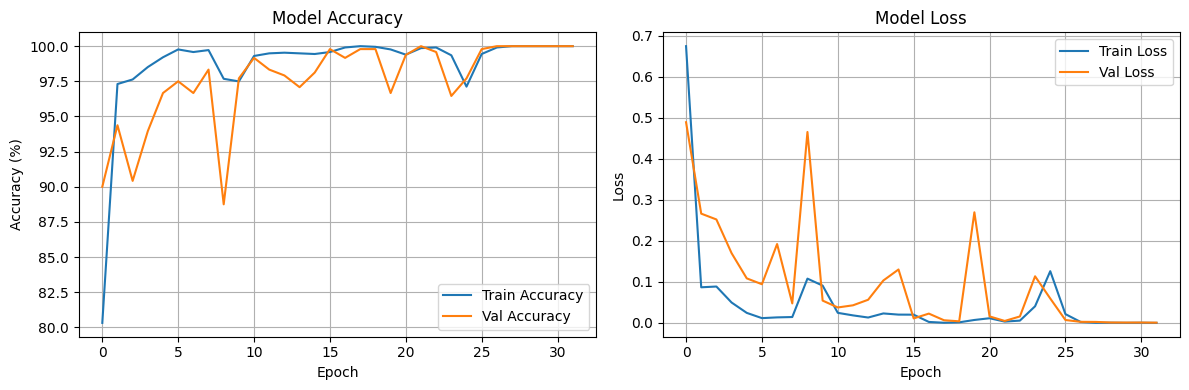

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_acc'], label='Train Accuracy')
axes[0].plot(history['val_acc'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_loss'], label='Train Loss')
axes[1].plot(history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 4. Feature Extraction

In [46]:
class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super(FeatureExtractor, self).__init__()
        self.features = nn.Sequential(*list(model.children())[:-1])
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return x

feature_extractor = FeatureExtractor(model)
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("Feature extractor created")

Feature extractor created


In [47]:
def extract_features(model, data_loader, device):
    features = []
    labels = []
    
    model.eval()
    with torch.no_grad():
        for images, lbls in tqdm(data_loader, desc='Extracting features'):
            images = images.to(device)
            feats = model(images)
            features.append(feats.cpu().numpy())
            labels.append(lbls.numpy())
    
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    return features, labels

print("Extracting features from training data...")
X_train_features, y_train_encoded = extract_features(feature_extractor, train_loader, device)

print("Extracting features from validation data...")
X_val_features, y_val_encoded = extract_features(feature_extractor, val_loader, device)

print(f"\nTraining features shape: {X_train_features.shape}")
print(f"Validation features shape: {X_val_features.shape}")

Extracting features from training data...


Extracting features: 100%|██████████| 68/68 [00:09<00:00,  7.08it/s]


Extracting features from validation data...


Extracting features: 100%|██████████| 15/15 [00:01<00:00,  8.23it/s]


Training features shape: (2154, 1280)
Validation features shape: (480, 1280)


## 5. Ensemble Model Training

In [48]:
print("Training KNN Classifier...")
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_features, y_train_encoded)
knn_pred = knn.predict(X_val_features)
knn_accuracy = accuracy_score(y_val_encoded, knn_pred)
print(f"KNN Accuracy: {knn_accuracy:.4f}")

print("\nTraining Logistic Regression...")
lr = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)
lr.fit(X_train_features, y_train_encoded)
lr_pred = lr.predict(X_val_features)
lr_accuracy = accuracy_score(y_val_encoded, lr_pred)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

print("\nTraining SVC...")
svc = SVC(kernel='rbf', probability=True, random_state=42)
svc.fit(X_train_features, y_train_encoded)
svc_pred = svc.predict(X_val_features)
svc_accuracy = accuracy_score(y_val_encoded, svc_pred)
print(f"SVC Accuracy: {svc_accuracy:.4f}")

Training KNN Classifier...
KNN Accuracy: 1.0000

Training Logistic Regression...
Logistic Regression Accuracy: 1.0000

Training SVC...
SVC Accuracy: 1.0000


In [49]:
print("Training Voting Classifier...")
voting_clf = VotingClassifier(
    estimators=[
        ('knn', knn),
        ('lr', lr),
        ('svc', svc)
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf.fit(X_train_features, y_train_encoded)
voting_pred = voting_clf.predict(X_val_features)
voting_accuracy = accuracy_score(y_val_encoded, voting_pred)

print(f"\nEnsemble Voting Classifier Accuracy: {voting_accuracy:.4f}")

print("\n" + "="*50)
print("Model Comparison:")
print("="*50)
print(f"KNN:                 {knn_accuracy:.4f}")
print(f"Logistic Regression: {lr_accuracy:.4f}")
print(f"SVC:                 {svc_accuracy:.4f}")
print(f"Voting Ensemble:     {voting_accuracy:.4f}")
print("="*50)

Training Voting Classifier...

Ensemble Voting Classifier Accuracy: 1.0000

Model Comparison:
KNN:                 1.0000
Logistic Regression: 1.0000
SVC:                 1.0000
Voting Ensemble:     1.0000


## 6. Evaluation

In [50]:
print("Classification Report for Voting Ensemble:")
print(classification_report(y_val_encoded, voting_pred, 
                          target_names=label_encoder.classes_))

Classification Report for Voting Ensemble:
              precision    recall  f1-score   support

          ba       1.00      1.00      1.00        24
          ca       1.00      1.00      1.00        24
          da       1.00      1.00      1.00        24
         dha       1.00      1.00      1.00        24
          ga       1.00      1.00      1.00        24
          ha       1.00      1.00      1.00        24
          ja       1.00      1.00      1.00        24
          ka       1.00      1.00      1.00        24
          la       1.00      1.00      1.00        24
          ma       1.00      1.00      1.00        24
          na       1.00      1.00      1.00        24
         nga       1.00      1.00      1.00        24
         nya       1.00      1.00      1.00        24
          pa       1.00      1.00      1.00        24
          ra       1.00      1.00      1.00        24
          sa       1.00      1.00      1.00        24
          ta       1.00      1.00     

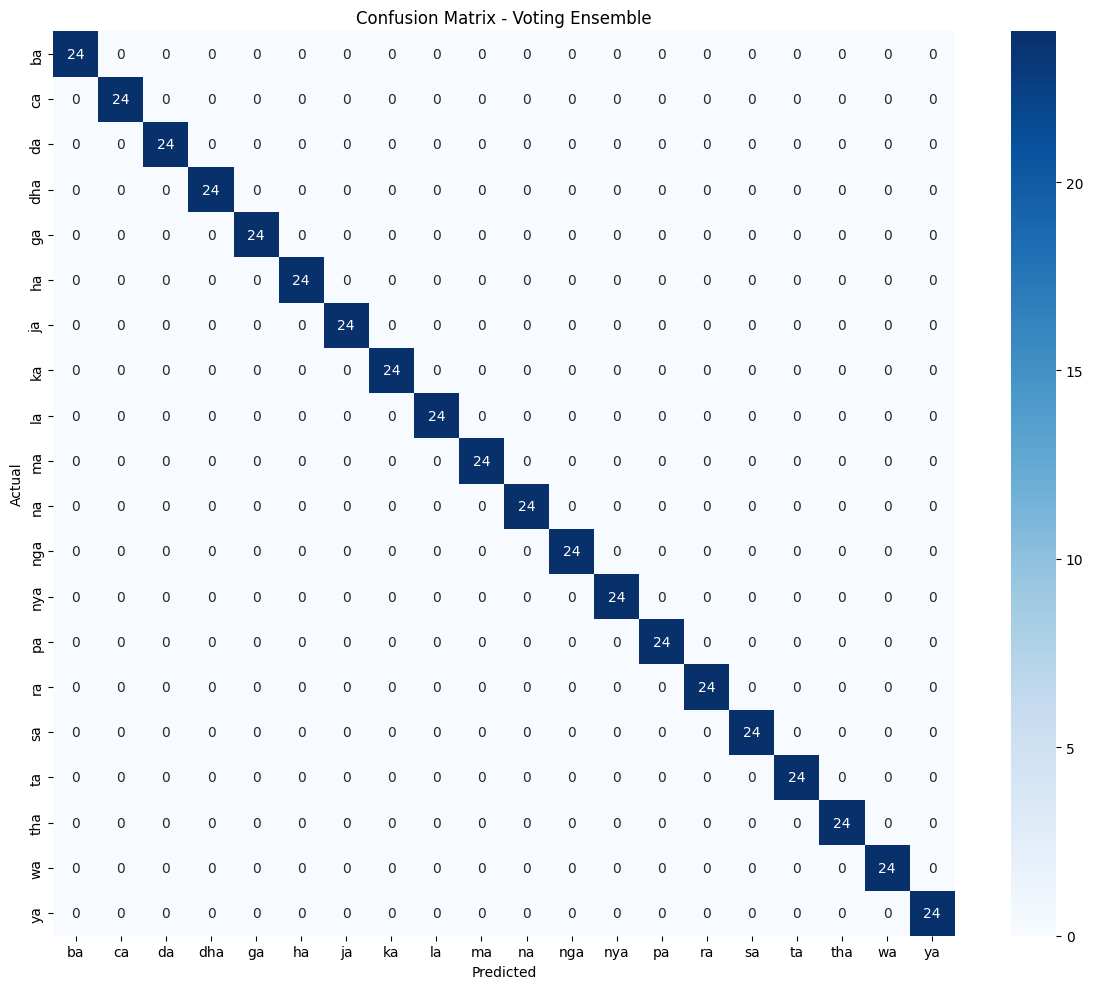

In [51]:
cm = confusion_matrix(y_val_encoded, voting_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Voting Ensemble')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()